# 💼  SteamSpy Investigation Report: Price, Playtime & Popularity


### Case file style: Detective-themed exploratory data analysis on Steam games using SteamSpy data.
### Each section follows the format: Question = Suspicion, Code = Investigation, Insight =Verdict



## 🧾 Case Metadata (What this notebook contains)

**Data source: SteamSpy aggregated dataset (saved as steam_games.csv in this notebook).**

**Main focus: price, average_forever (average playtime), positive, negative, and metadata such as publisher, developer.**

**Output: EDA, plots, grouped summaries, and top/bottom lists.**

## Scene of the Crime — Setup & Dependencies

In [1]:
import requests
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Chain of Custody — Data Collection & Loading
### Filed the first report by scraping clues straight from the source , gathering raw evidence before it disappears

In [2]:
# SteamSpy provides aggregated data for thousands of games
url = "https://steamspy.com/api.php?request=all"
res = requests.get(url)
data = res.json()

# Convert to DataFrame
df = pd.DataFrame(data).T  # transpose because the JSON is nested by appid

# Keep useful columns
df = df[['name', 'developer', 'publisher', 'positive', 'negative',
         'owners', 'price', 'score_rank', 'userscore', 'average_forever']]

# Clean up
df['owners'] = df['owners'].str.replace(',', '').str.split('-').str[1].astype(float)
df['price'] = df['price'].astype(float) / 100  # SteamSpy gives price in cents

# Add index column
df.reset_index(inplace=True)
df.rename(columns={'index': 'Index'}, inplace=True)
df['Index'] = df['Index'].astype(int) + 1  # start from 1

print(f"✅ Total games fetched: {len(df)}")
print(df.head())

# Save with index column
df.to_csv("steam_games.csv", index=False)
print("💾 Saved as steam_games.csv")


✅ Total games fetched: 1000
     Index                              name         developer  \
0      731  Counter-Strike: Global Offensive             Valve   
1  1172471                      Apex Legends           Respawn   
2   578081               PUBG: BATTLEGROUNDS  PUBG Corporation   
3  1623731                          Palworld        Pocketpair   
4      441                   Team Fortress 2             Valve   

         publisher positive negative  owners  price score_rank userscore  \
0            Valve  7642084  1173003     NaN   0.00                    0   
1  Electronic Arts   668053   326926     NaN   0.00                    0   
2    KRAFTON, Inc.  1520457  1037487     NaN   0.00                    0   
3       Pocketpair   358266    22443     NaN  29.99                    0   
4            Valve  1044264   117208     NaN   0.00                    0   

  average_forever  
0           33540  
1           10135  
2           23498  
3            3842  
4           22717 

## Evidence Check — Initial Data Exploration

### Load the Dataset

In [3]:
df = pd.read_csv('steam_games.csv')

### Inspect the Dataset

In [4]:
# shape of dataset
df.shape

(1000, 11)

In [5]:
# first five rows
df.head()

,Index,name,developer,publisher,positive,negative,owners,price,score_rank,userscore,average_forever
0,731,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,NaN,0.00,NaN,0,33540
1,1172471,Apex Legends,Respawn,Electronic Arts,668053,326926,NaN,0.00,NaN,0,10135
2,578081,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,NaN,0.00,NaN,0,23498
3,1623731,Palworld,Pocketpair,Pocketpair,358266,22443,NaN,29.99,NaN,0,3842
4,441,Team Fortress 2,Valve,Valve,1044264,117208,NaN,0.00,NaN,0,22717


In [6]:
df.tail()

,Index,name,developer,publisher,positive,negative,owners,price,score_rank,userscore,average_forever
995,1044721,Farthest Frontier,Crate Entertainment,Crate Entertainment,16780,2724,NaN,34.99,NaN,0,2177
996,668581,Atomic Heart,Mundfish,"Focus Entertainment, 4Divinity",31167,6828,NaN,59.99,NaN,0,865
997,544751,SOULCALIBUR VI,"BANDAI NAMCO Studios Inc., Dimps Corporation",BANDAI NAMCO Entertainment,11147,2394,NaN,59.99,NaN,0,671
998,972661,Spiritfarer: Farewell Edition,Thunder Lotus,Thunder Lotus,44192,2225,NaN,29.99,NaN,0,1060
999,1150691,OMORI,"OMOCAT, LLC","OMOCAT, LLC",78023,2214,NaN,19.99,NaN,0,1051


In [7]:
df.describe()

,Index,positive,negative,owners,price,score_rank,userscore,average_forever
count,1.000000e+03,1.000000e+03,1.000000e+03,0.0,1000.000000,0.0,1000.0,1000.000000
mean,6.284040e+05,9.274577e+04,1.390409e+04,NaN,19.327120,NaN,0.0,2481.988000
std,6.146411e+05,2.890006e+05,5.581388e+04,NaN,17.821149,NaN,0.0,3805.419979
min,1.100000e+01,0.000000e+00,1.000000e+00,NaN,0.000000,NaN,0.0,0.000000
25%,2.281360e+05,1.594800e+04,2.154750e+03,NaN,1.990000,NaN,0.0,567.000000
50%,4.100210e+05,3.571400e+04,4.391000e+03,NaN,19.990000,NaN,0.0,1211.000000
75%,8.950010e+05,8.042100e+04,1.009825e+04,NaN,29.990000,NaN,0.0,2659.750000
max,3.241661e+06,7.642084e+06,1.173003e+06,NaN,69.990000,NaN,0.0,44082.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Index            1000 non-null   int64  
 1   name             1000 non-null   object 
 2   developer        1000 non-null   object 
 3   publisher        999 non-null    object 
 4   positive         1000 non-null   int64  
 5   negative         1000 non-null   int64  
 6   owners           0 non-null      float64
 7   price            1000 non-null   float64
 8   score_rank       0 non-null      float64
 9   userscore        1000 non-null   int64  
 10  average_forever  1000 non-null   int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 86.1+ KB


In [9]:
df.dtypes

Index                int64
name                object
developer           object
publisher           object
positive             int64
negative             int64
owners             float64
price              float64
score_rank         float64
userscore            int64
average_forever      int64
dtype: object

In [10]:
df.dtypes.value_counts()

int64      5
object     3
float64    3
Name: count, dtype: int64

In [11]:
# get the datasets column name 
df.columns

Index(['Index', 'name', 'developer', 'publisher', 'positive', 'negative',
       'owners', 'price', 'score_rank', 'userscore', 'average_forever'],
      dtype='object')

## Data Preprocessing (Cleaning, Formatting, Structuring)

In [12]:
df.isnull().sum()

Index                 0
name                  0
developer             0
publisher             1
positive              0
negative              0
owners             1000
price                 0
score_rank         1000
userscore             0
average_forever       0
dtype: int64

### drop the columns with 100% missing values 

In [13]:
cols_dropped = df.columns[df.isna().all()].tolist()

df = df.drop(cols_dropped,axis=1)
df = df.drop('userscore',axis=1)

In [14]:
df.shape

(1000, 8)

In [15]:
df['publisher'] = df['publisher'].fillna("Unknown")

In [16]:
df.isnull().sum()

Index              0
name               0
developer          0
publisher          0
positive           0
negative           0
price              0
average_forever    0
dtype: int64

### Check for Duplicates in DataFrame

In [17]:
df[df.duplicated]

,Index,name,developer,publisher,positive,negative,price,average_forever


In [18]:
df.drop_duplicates().shape

(1000, 8)

In [19]:
df.rename(columns={'Index': 'app_id'}, inplace=True)
df.head()

df.reset_index(drop=True, inplace=True)
df.index = df.index + 1
df.index.name = 'Index'

df.head()

,app_id,name,developer,publisher,positive,negative,price,average_forever
Index,,,,,,,,
1,731,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,0.00,33540
2,1172471,Apex Legends,Respawn,Electronic Arts,668053,326926,0.00,10135
3,578081,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,0.00,23498
4,1623731,Palworld,Pocketpair,Pocketpair,358266,22443,29.99,3842
5,441,Team Fortress 2,Valve,Valve,1044264,117208,0.00,22717



### * Observation:
    There are no duplicate observations in the datasets 

In [20]:
df.skew(numeric_only=True)

app_id              1.596489
positive           18.744652
negative           15.896874
price               0.846642
average_forever     4.312410
dtype: float64

## Outlier Detection

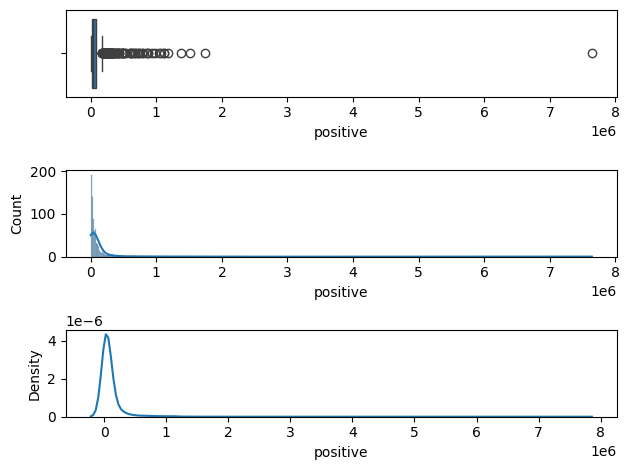

In [21]:
plt.subplot(311)
sns.boxplot(x = df.positive)
plt.subplot(312)
sns.histplot(x = df.positive, kde = True)
plt.subplot(313)
sns.kdeplot(x = df.positive)

plt.tight_layout() 
plt.show();

In [22]:
df.positive.describe()

count    1.000000e+03
mean     9.274577e+04
std      2.890006e+05
min      0.000000e+00
25%      1.594800e+04
50%      3.571400e+04
75%      8.042100e+04
max      7.642084e+06
Name: positive, dtype: float64

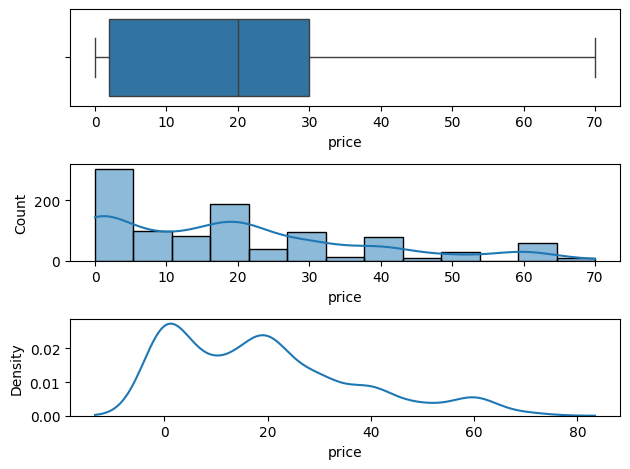

In [23]:
plt.subplot(311)
sns.boxplot(x = df.price)
plt.subplot(312)
sns.histplot(x = df.price, kde = True)
plt.subplot(313)
sns.kdeplot(x = df.price)

plt.tight_layout() 
plt.show();

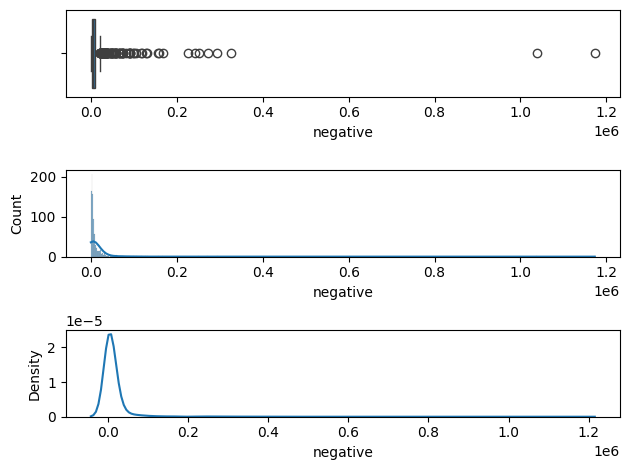

In [24]:
plt.subplot(311)
sns.boxplot(x = df.negative)
plt.subplot(312)
sns.histplot(x = df.negative, kde = True)
plt.subplot(313)
sns.kdeplot(x = df.negative)

plt.tight_layout() 
plt.show();

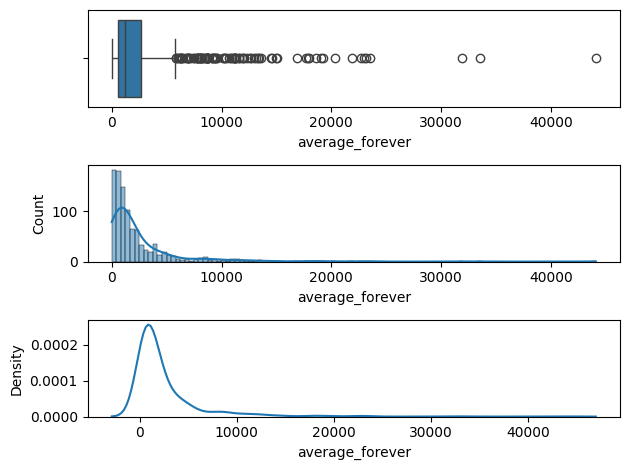

In [25]:
plt.subplot(311)
sns.boxplot(x = df.average_forever)
plt.subplot(312)
sns.histplot(x = df.average_forever, kde = True)
plt.subplot(313)
sns.kdeplot(x = df.average_forever)

plt.tight_layout() 
plt.show();

## 🕵️‍♂️ Suspect List: Top Developers Running the Show

In [26]:
top_developers = df['developer'].value_counts().head(10)
top_developers

developer
Valve                                                                    27
CAPCOM Co., Ltd.                                                         17
Bethesda Game Studios                                                     9
DICE                                                                      8
Ubisoft Montreal                                                          7
Infinity Ward                                                             7
Sports Interactive                                                        6
Bohemia Interactive                                                       6
CREATIVE ASSEMBLY, Feral Interactive (Mac), Feral Interactive (Linux)     6
FromSoftware, Inc.                                                        6
Name: count, dtype: int64

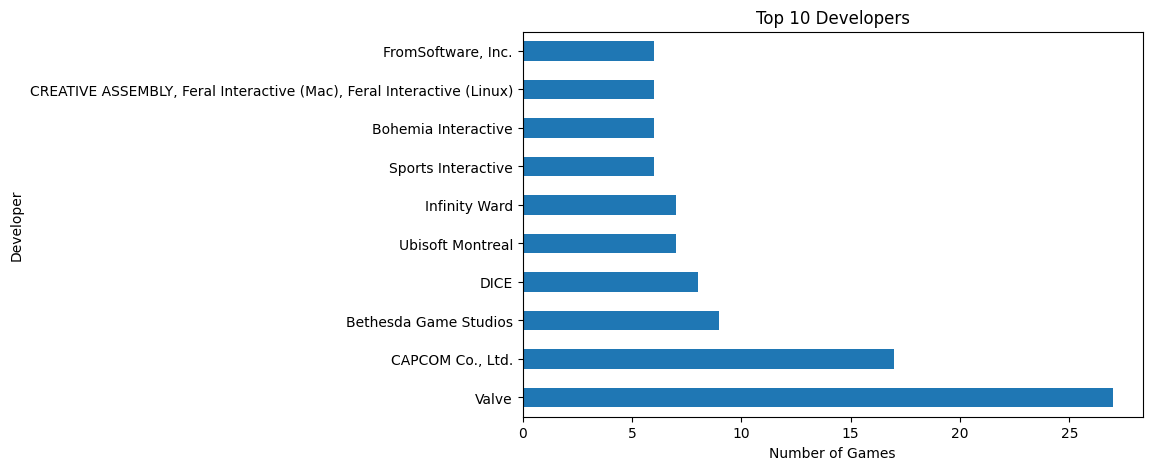

In [60]:
# top_developers = df['developer'].value_counts().head(10)

top_developers.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Developers")
plt.xlabel("Number of Games")
plt.ylabel("Developer")
plt.show()

### Insight 🧐
        A small group of developers commands most of the output, while a long tail of smaller studios enriches the market with niche and diverse titles

## 🏢 Powerhouses in the Shadows: Top Publishers

In [27]:
top_publishers = df['publisher'].value_counts().head(10)
top_publishers


publisher
Electronic Arts        40
Valve                  30
Bethesda Softworks     29
Ubisoft                28
Xbox Game Studios      21
2K                     20
SEGA                   18
Activision             17
CAPCOM Co., Ltd.       17
Paradox Interactive    15
Name: count, dtype: int64

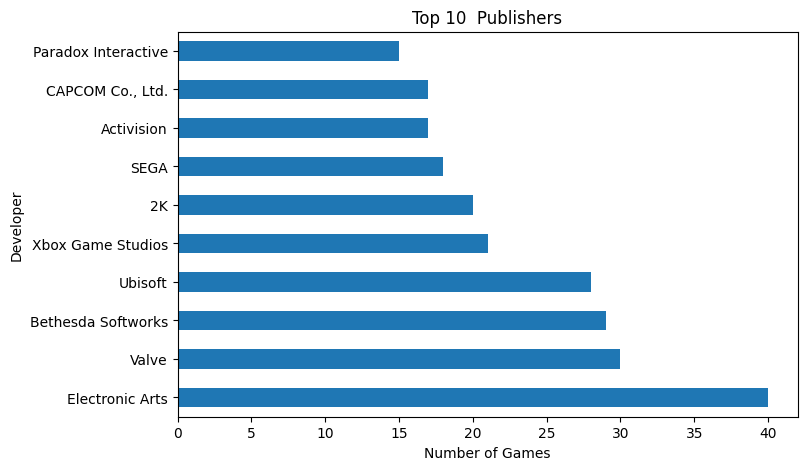

In [71]:
top_publishers.plot(kind='barh', figsize=(8,5))
plt.title("Top 10  Publishers")
plt.xlabel("Number of Games")
plt.ylabel("Developer")
plt.show()

### Insight 🧐
     A handful of publishers dominate the landscape, with numerous smaller publishers contributing depth and variety to the overall ecosystem.

## ⭐ Case File: Games With the Highest Positive Comments

In [28]:
top_positive = df.nlargest(10, 'positive')[['name', 'positive']]
top_positive


,name,positive
Index,,
1,Counter-Strike: Global Offensive,7642084
9,Grand Theft Auto V Legacy,1739980
3,PUBG: BATTLEGROUNDS,1520457
18,Terraria,1373979
25,Tom Clancy's Rainbow Six Siege,1172854
23,Garry's Mod,1122546
8,Black Myth: Wukong,1111720
26,Rust,1071135
5,Team Fortress 2,1044264


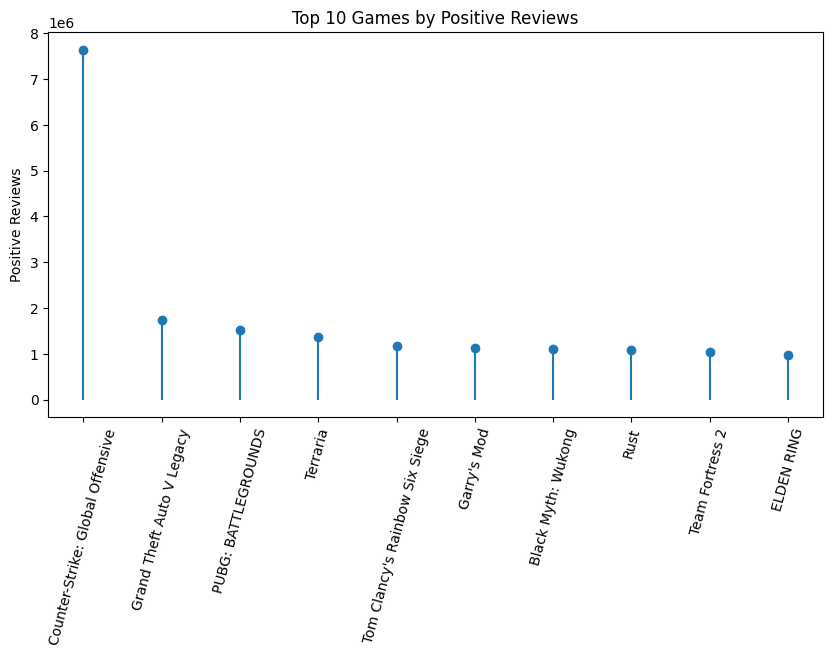

In [ ]:
# top_positive = df.nlargest(10, 'positive')[['name', 'positive']]

plt.figure(figsize=(10,5))
plt.stem(top_positive['name'], top_positive['positive'], basefmt=" ") 
plt.xticks(rotation=75)
plt.title("Top 10 Games by Positive Reviews")
plt.ylabel("Positive Reviews")
plt.show()

### Insight 🧐
    A select few games attract overwhelmingly positive engagement, suggesting strong gameplay satisfaction and a loyal player base

## ⚠️ Red Flags: Games With the Highest Negative Comments

In [29]:
top_negative = df.nlargest(10, 'negative')[['name', 'negative']]
top_negative


,name,negative
Index,,
1,Counter-Strike: Global Offensive,1173003
3,PUBG: BATTLEGROUNDS,1037487
2,Apex Legends,326926
6,Call of Duty: Modern Warfare II,294520
13,War Thunder,272617
9,Grand Theft Auto V Legacy,250576
15,HELLDIVERS 2,241752
25,Tom Clancy's Rainbow Six Siege,225730
39,Dead by Daylight,166993


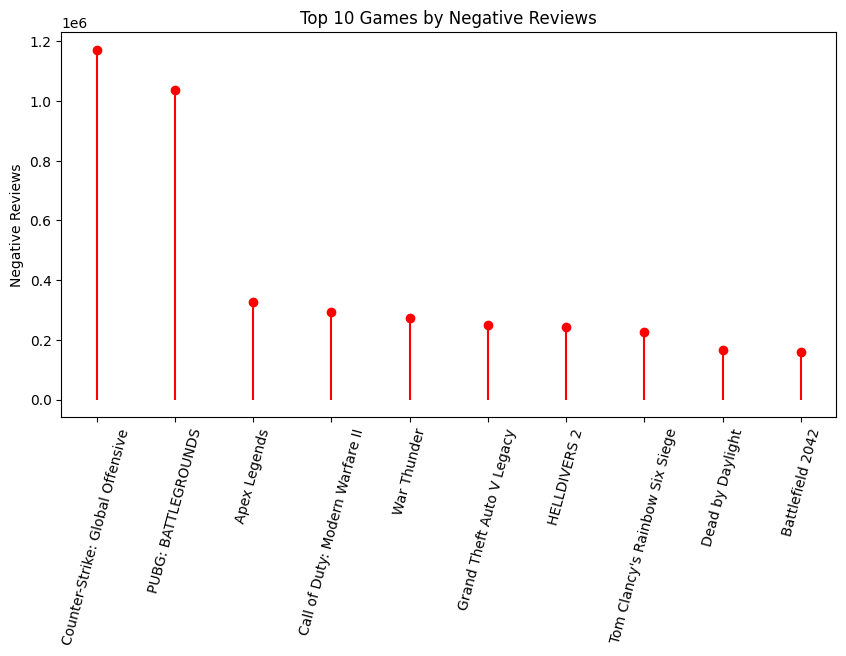

In [ ]:
# top_negative = df.nlargest(10, 'negative')[['name', 'negative']]

plt.figure(figsize=(10,5))
plt.stem(top_negative['name'], top_negative['negative'], linefmt="r-", markerfmt="ro", basefmt=" ")
plt.xticks(rotation=75)
plt.title("Top 10 Games by Negative Reviews")
plt.ylabel("Negative Reviews")
plt.show()




### Insight 🧐
    Certain titles accumulate disproportionately high negative feedback, indicating possible issues in quality, updates, or player expectations

## 💸 High-Roller Evidence: The Most Expensive Games on Steam

In [66]:
top_expensive = df.nlargest(20, 'price')[['name', 'price']]
top_expensive

,name,price
Index,,
14,Monster Hunter Wilds,69.99
135,EA SPORTS FC 24,69.99
203,EA SPORTS FC 25,69.99
246,Need for Speed Heat,69.99
251,Starfield,69.99
581,Dragon's Dogma 2,69.99
584,DRAGON BALL: Sparking! ZERO,69.99
989,STAR WARS Jedi: Survivor,69.99
361,POSTAL,67.95


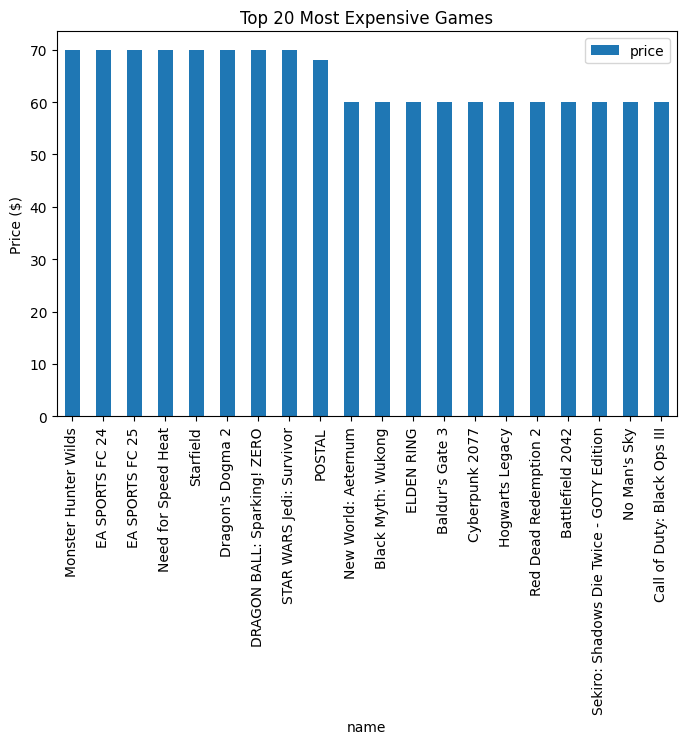

In [70]:
# top_expensive = df.nlargest(5, 'price')[['name', 'price']]

top_expensive.plot(kind='bar', x='name', y='price', figsize=(8,5))
plt.title("Top 20 Most Expensive Games")
plt.ylabel("Price ($)")
plt.xticks(rotation=90)
plt.show()



### Insight 🧐
    Only a small segment of titles falls into the premium price category, hinting at selective pricing strategies aimed at perceived value or brand strength.

## 📊 Money Trail: Price Distribution Analysis

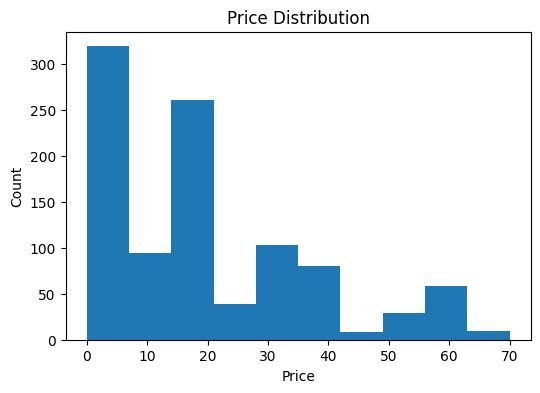

In [62]:
plt.figure(figsize=(6,4))
plt.hist(df['price'])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### Insight 🧐
      The price distribution is heavily skewed toward lower-priced titles, showing that budget-friendly games dominate the market

## ⏱️ Time Sink Files: Most Played Games by Average Playtime

In [36]:
top_played = df.nlargest(10, 'average_forever')[['name', 'average_forever']]
top_played

top_played['average_hours'] = (top_played['average_forever'] / 60).round(2)
top_played



,name,average_forever,average_hours
Index,,,
245,FINAL FANTASY XIV Online,44082,734.70
1,Counter-Strike: Global Offensive,33540,559.00
263,Crosshair X,31937,532.28
3,PUBG: BATTLEGROUNDS,23498,391.63
493,Football Manager 2021,23159,385.98
26,Rust,22928,382.13
5,Team Fortress 2,22717,378.62
461,Football Manager 2022,21896,364.93
146,Europa Universalis IV,20291,338.18


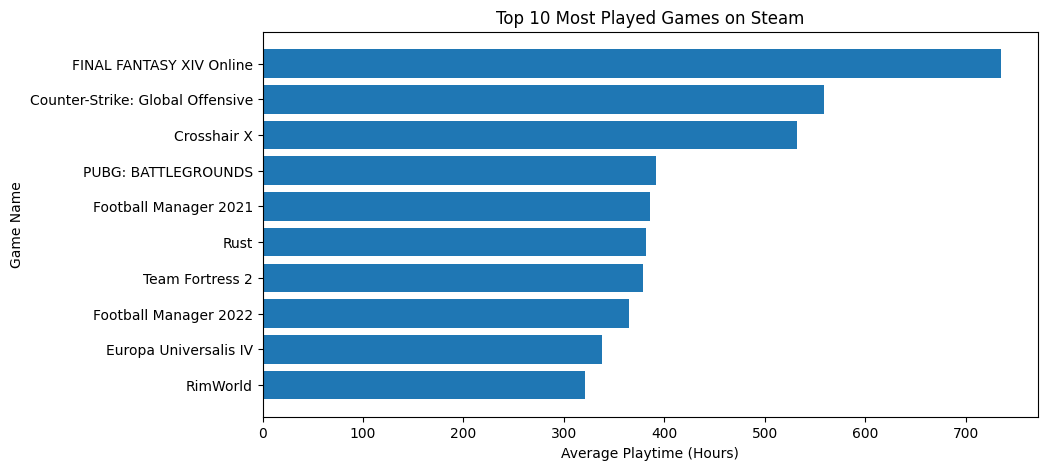

In [37]:
plt.figure(figsize=(10,5))
plt.barh(top_played['name'], top_played['average_hours'])
plt.xlabel("Average Playtime (Hours)")
plt.ylabel("Game Name")
plt.title("Top 10 Most Played Games on Steam")
plt.gca().invert_yaxis()  # so highest stays on top
plt.show()

### Insight 🧐
    Average playtime varies widely, with a few highly engaging games keeping players invested while most titles see moderate or short sessions

## 🕵️‍♂️ Do Masterminds Matter? Developer ↔ Positive Comments

In [41]:
positive_developers = pd.crosstab(index=df['developer'],
            columns='Total',
            values=df['positive'],
            aggfunc='sum')

top_10_postive_developers = positive_developers.sort_values(by='Total' , ascending= False)[:10]
# positive_developers.head()
top_10_postive_developers

col_0,Total
developer,
Valve,11515538
Facepunch Studios,2193681
"FromSoftware, Inc.",1896285
Rockstar North,1778575
CD PROJEKT RED,1691627
"CAPCOM Co., Ltd.",1627612
PUBG Corporation,1520457
Ubisoft Montreal,1433113
Re-Logic,1373979


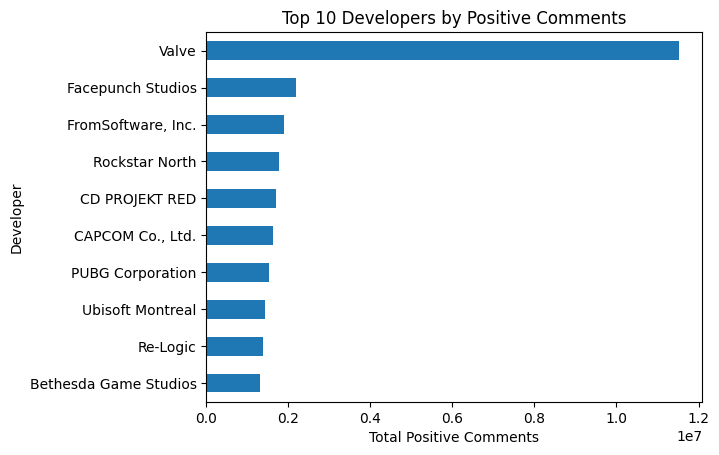

In [42]:
top_10_postive_developers.plot(kind='barh', legend=False)
plt.title('Top 10 Developers by Positive Comments')
plt.xlabel('Total Positive Comments')
plt.ylabel('Developer')

plt.gca().invert_yaxis()  # largest on top
plt.show()

### Insight 🧐
    Some developers consistently receive higher positive feedback, indicating stronger player satisfaction and polished game quality

## 💵 Does Money Buy Love? Positive Comments ↔ Price

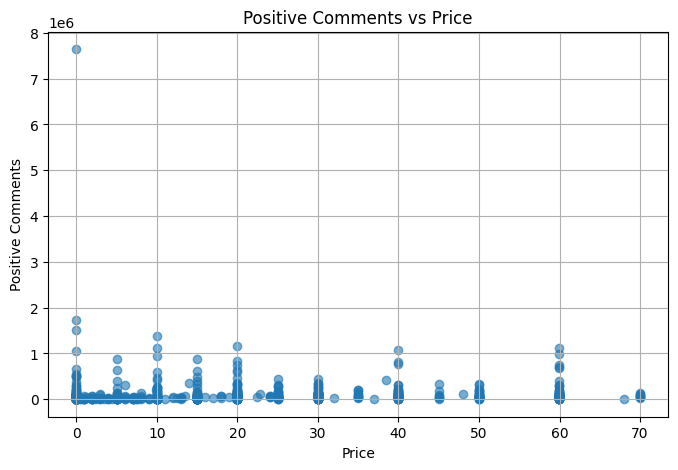

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['price'], df['positive'], alpha=0.6)
plt.title('Positive Comments vs Price')
plt.xlabel('Price')
plt.ylabel('Positive Comments')
plt.grid(True)
plt.show()


In [44]:
price_positive = pd.crosstab(index= df['price'],
                columns= 'Total',
                values= df['positive'],
                aggfunc='sum'
            )

price_positive.sort_values(by='Total',ascending=False)



col_0,Total
price,
0.00,24369988
19.99,14786282
59.99,8877244
9.99,8614331
39.99,8172433
29.99,6964761
14.99,5546436
4.99,3323839
24.99,3130080


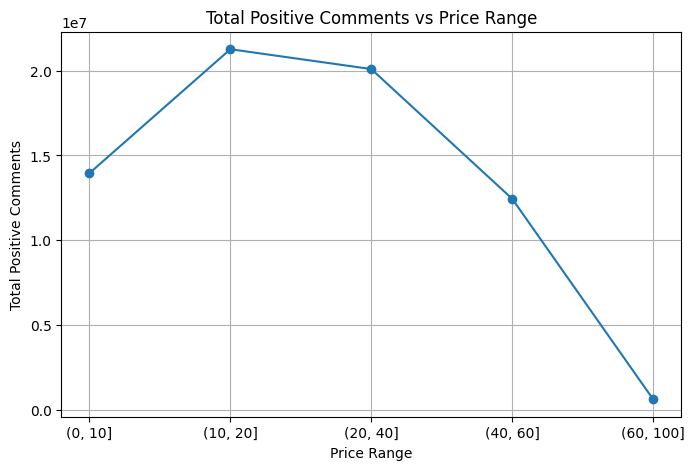

In [45]:

# Create price ranges
df['price_range'] = pd.cut(df['price'], bins=[0,10,20,40,60,100])

# Sum of positive comments per price range
price_positive = pd.crosstab(
    index=df['price_range'],
    columns='Total',
    values=df['positive'],
    aggfunc='sum'
)

# Plot
plt.figure(figsize=(8,5))
plt.plot(price_positive.index.astype(str),  # X-axis = price range
         price_positive['Total'],           # Y-axis = total positives
         marker='o')

plt.title('Total Positive Comments vs Price Range')
plt.xlabel('Price Range')
plt.ylabel('Total Positive Comments')
plt.grid(True)
plt.show()


### Insight 🧐
    This suggests that lower-priced titles attract larger player bases and generate more engagement, leading to higher counts of positive reviews.

## ⚠️ The Price of Disappointment: Negative Comments ↔ Price

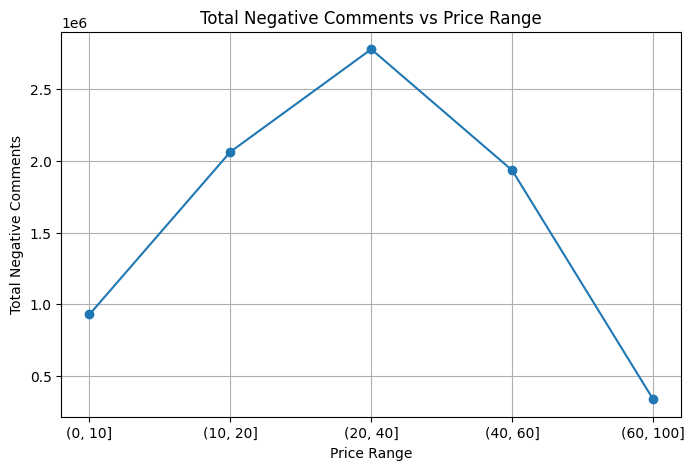

In [72]:

negative_price = pd.crosstab(index=df['price_range'],
                             columns='Total',
                             values=df['negative'],
                             aggfunc='sum'
                             )

# Plot 
plt.figure(figsize=(8,5))
plt.plot(negative_price.index.astype(str),
         negative_price['Total'],
         marker='o'
         )

plt.title('Total Negative Comments vs Price Range')
plt.xlabel('Price Range')
plt.ylabel('Total Negative Comments')
plt.grid(True)
plt.show()


### Insight 🧐
    Mid-priced titles seem to attract the most criticism — possibly because they sell in high volume but don’t always meet player expectations compared to premium titles.

## ⏳ Time vs Money Trail: Price ↔ Average Playtime

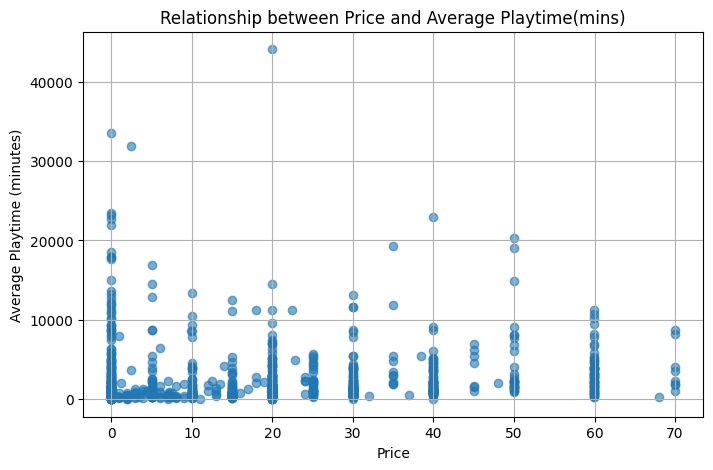

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['price'],df['average_forever'],alpha=0.6)
plt.title('Relationship between Price and Average Playtime(mins)')
plt.xlabel('Price')
plt.ylabel('Average Playtime (minutes)')
plt.grid(True)
plt.show()


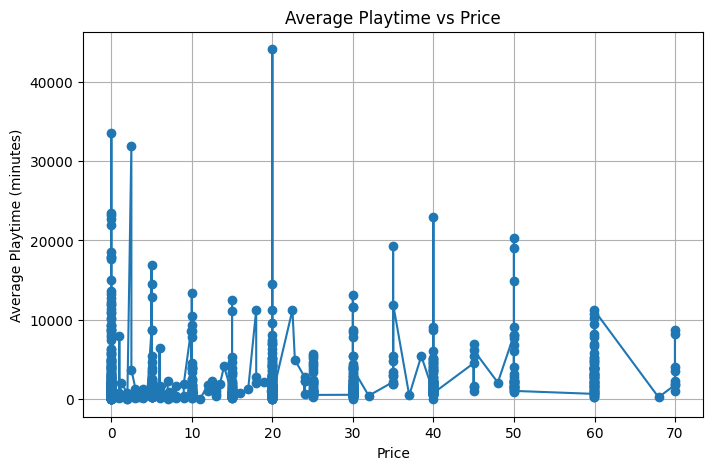

In [51]:
import matplotlib.pyplot as plt

# Sort by price
df_sorted = df.sort_values(by='price')

plt.figure(figsize=(8,5))
plt.plot(df_sorted['price'], df_sorted['average_forever'], marker='o', linestyle='-')
plt.title('Average Playtime vs Price')
plt.xlabel('Price')
plt.ylabel('Average Playtime (minutes)')
plt.grid(True)
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_14424\1573699403.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_playtime = df.groupby('price_range')['average_forever'].mean()


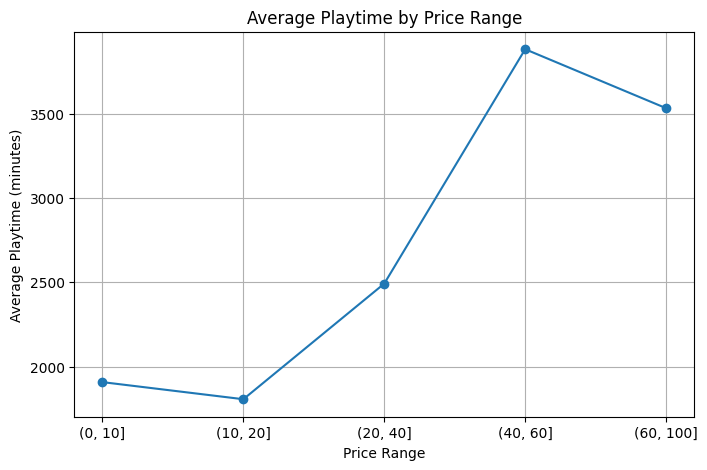

In [52]:
avg_playtime = df.groupby('price_range')['average_forever'].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_playtime.index.astype(str), avg_playtime.values, marker='o')
plt.title('Average Playtime by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Playtime (minutes)')
plt.grid(True)
plt.show()

### Insight 🧐
    This suggests that premium titles often deliver deeper or more engaging experiences, keeping players invested for longer session

## ⭐ Engagement Evidence: Positive Comments ↔ Average Playtime

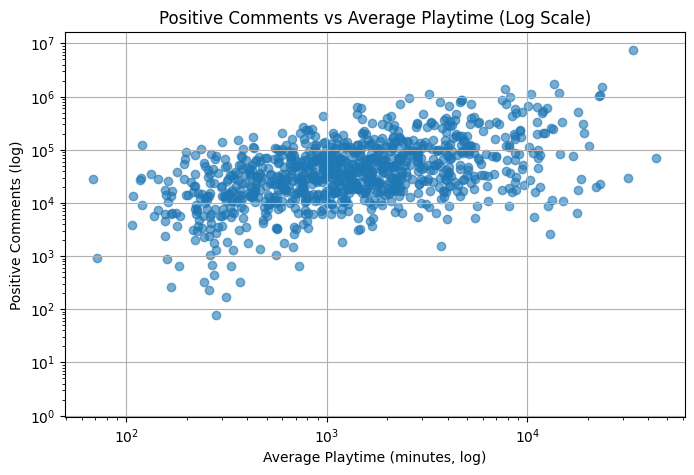

In [53]:
plt.figure(figsize=(8,5))
plt.scatter(df['average_forever'], df['positive'], alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title('Positive Comments vs Average Playtime (Log Scale)')
plt.xlabel('Average Playtime (minutes, log)')
plt.ylabel('Positive Comments (log)')
plt.grid(True)
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_14424\1806708417.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  playtime_positive = df.groupby('playtime_range')['positive'].mean()


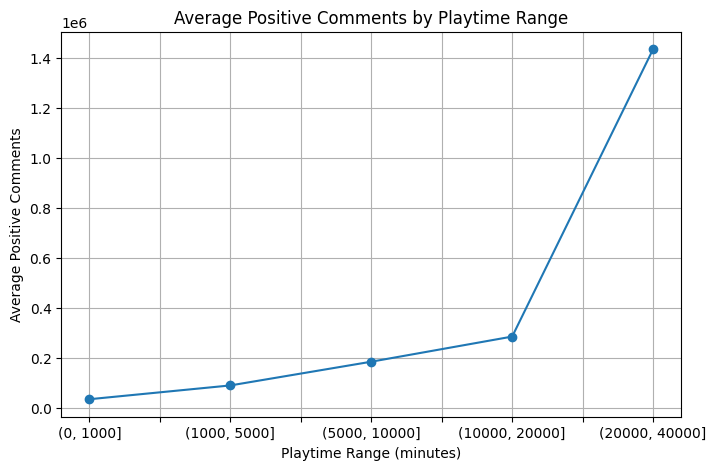

In [54]:
df['playtime_range'] = pd.cut(df['average_forever'], bins=[0,1000,5000,10000,20000,40000])
playtime_positive = df.groupby('playtime_range')['positive'].mean()

playtime_positive.plot(kind='line', marker='o', figsize=(8,5))
plt.title('Average Positive Comments by Playtime Range')
plt.xlabel('Playtime Range (minutes)')
plt.ylabel('Average Positive Comments')
plt.grid(True)
plt.show()


### Insight 🧐
    Games with longer average playtime tend to accumulate more positive comments, reflecting strong engagement and player approval.

## 🔥 Trouble Brewing: Negative Comments ↔ Average Playtime

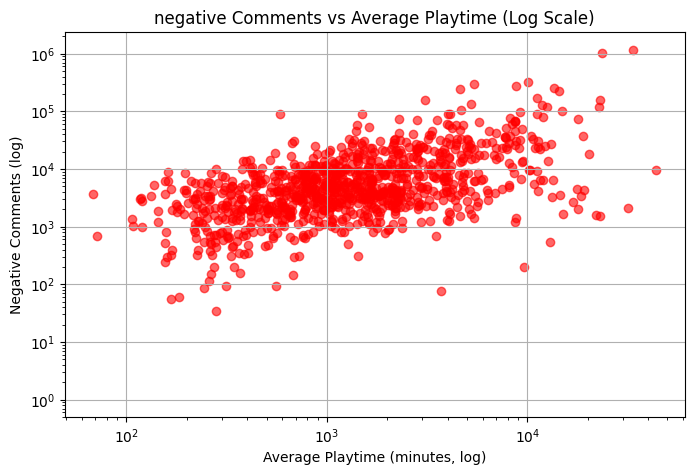

In [55]:
plt.figure(figsize=(8,5))
plt.scatter(df['average_forever'], df['negative'], alpha=0.6,color='red')
plt.xscale('log')
plt.yscale('log')
plt.title('negative Comments vs Average Playtime (Log Scale)')
plt.xlabel('Average Playtime (minutes, log)')
plt.ylabel('Negative Comments (log)')
plt.grid(True)
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_14424\71968752.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  playtime_negative = df.groupby('playtime_range')['negative'].mean()


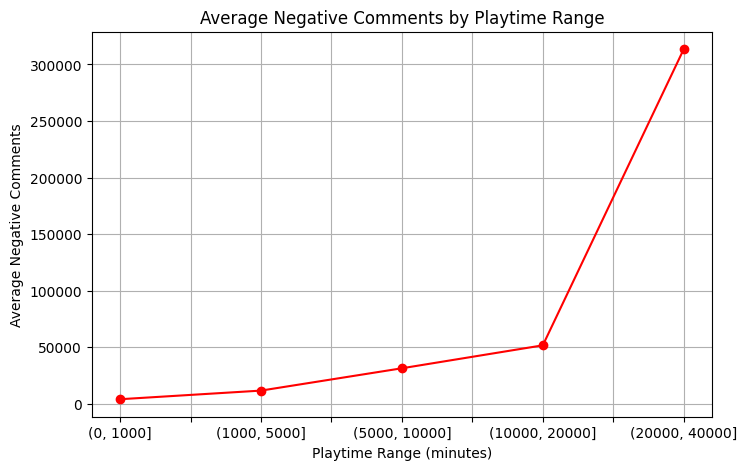

In [56]:

playtime_negative = df.groupby('playtime_range')['negative'].mean()

# Plot line chart
playtime_negative.plot(kind='line', marker='o', color='red', figsize=(8,5))
plt.title('Average Negative Comments by Playtime Range')
plt.xlabel('Playtime Range (minutes)')
plt.ylabel('Average Negative Comments')
plt.grid(True)
plt.show()



### Insight 🧐
      Negative sentiment here likely reflects popularity + large player bases rather than poor quality — more players means more opportunities for negative feedback.

## ⏱️ Sentiment Under the Spotlight: Positive & Negative Comments ↔ Playtime

C:\Users\admin\AppData\Local\Temp\ipykernel_14424\1895823623.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  playtime_positive = df.groupby('playtime_range')['positive'].mean()
C:\Users\admin\AppData\Local\Temp\ipykernel_14424\1895823623.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  playtime_negative = df.groupby('playtime_range')['negative'].mean()


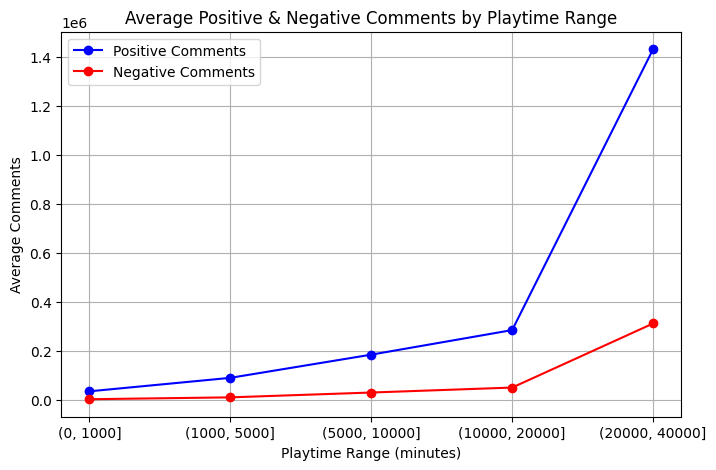

In [57]:
# Group averages for both
# Group averages for both
playtime_positive = df.groupby('playtime_range')['positive'].mean()
playtime_negative = df.groupby('playtime_range')['negative'].mean()

# Convert interval index to string labels
x_labels = playtime_positive.index.astype(str)

# Plot both on same figure
plt.figure(figsize=(8,5))
plt.plot(x_labels, playtime_positive.values, marker='o', label='Positive Comments', color='blue')
plt.plot(x_labels, playtime_negative.values, marker='o', label='Negative Comments', color='red')

plt.title('Average Positive & Negative Comments by Playtime Range')
plt.xlabel('Playtime Range (minutes)')
plt.ylabel('Average Comments')
plt.grid(True)
plt.legend()
plt.show()


### Insight 🧐
        This shows that player enjoyment is strongly tied to engagement: the more time players invest in a game, the more likely they are to leave positive reviews.

## 🕵️‍♂️ Following the Money & The Makers: Positive Comments ↔ Price ↔ Publisher/Developer

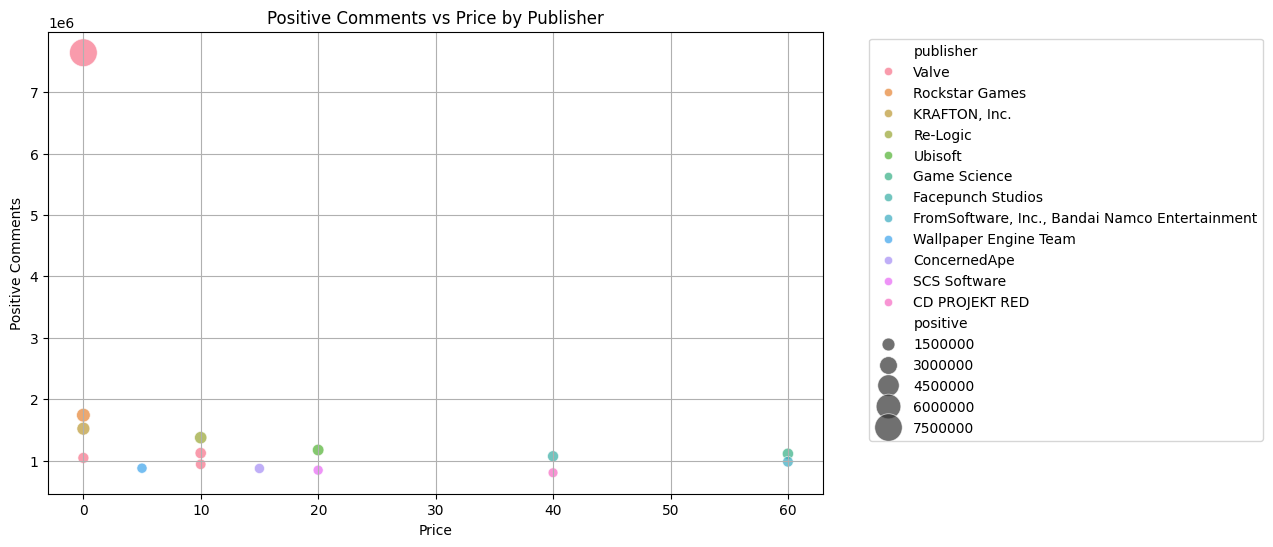

In [58]:


asc_sort = df.sort_values(by='positive', ascending=False)
top_15_postive_comments = asc_sort[:15]
len(top_15_postive_comments)



plt.figure(figsize=(10,6))

# Bubble chart — color by publisher
sns.scatterplot(
    data=top_15_postive_comments,
    x='price',
    y='positive',
    hue='publisher',   # or 'developer'
    size='positive',   # makes bubble size show engagement
    sizes=(50, 400),
    alpha=0.7
)

plt.title('Positive Comments vs Price by Publisher')
plt.xlabel('Price')
plt.ylabel('Positive Comments')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


### Insight 🧐
     Positive comments cluster around lower-priced games, and this trend is consistent across both major and smaller publishers/developers.

## ⚠️ The Blame Game: Negative Comments ↔ Price ↔ Publisher/Developer

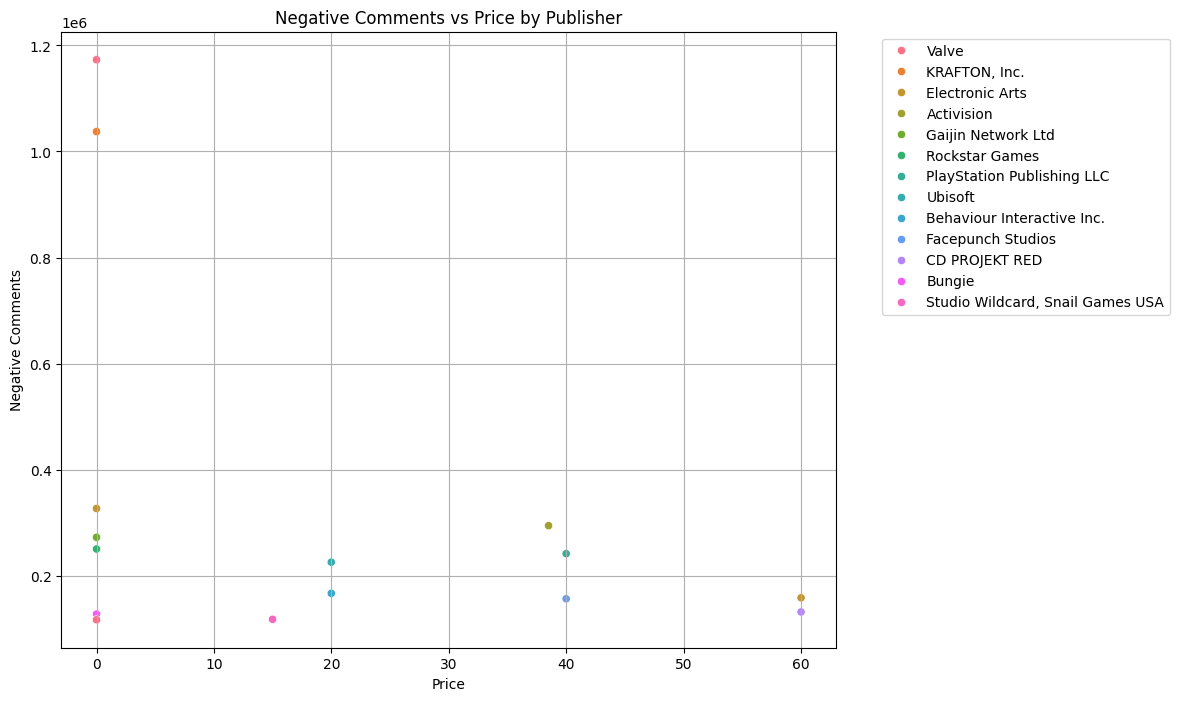

In [59]:
top_15_negative_comments = df.sort_values(by='negative',ascending=False)[:15]
len(top_15_negative_comments)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=top_15_negative_comments,
    x='price',
    y='negative',
    hue='publisher'
)

plt.title('Negative Comments vs Price by Publisher')
plt.xlabel('Price')
plt.ylabel('Negative Comments')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


### Insight 🧐
     This suggests that price alone doesn’t dictate dissatisfaction — players critique games across all price levels, depending more on quality and experience than cost.

## 🕵️‍♂️ Final Case Summary — What the Investigation Revealed

* **1️⃣ Price Didn’t Commit the Crime**

    Cheap games pulled the biggest crowds and the most praise.

    Negative comments were found scattered across every price bracket — no strong link to cost.

    Verdict: Price is innocent.

* **2️⃣ Playtime Was the Real Clue**

    The longer players stayed in a game, the more positive the reviews became.

    Short-playtime games left behind fewer traces — less engagement, less feedback.

    Verdict: High playtime = high satisfaction.

* **3️⃣ The Big Publishers Weren’t Calling All the Shots**

    A few studios dominated the charts, but smaller developers added flavor and variety to the case.

    Sentiment trends stayed consistent across both big and small names.

    Verdict: Reputation matters, but not as much as the experience.

* **4️⃣ Multivariate Cross-Examination**

    High price didn’t guarantee praise — players only reward games that deliver real depth.

    Both praise and complaints scaled with the size of the player base, not the size of the price tag.

    Verdict: Engagement drives emotion, not money.

* **5️⃣ The Final Truth**

    Engagement is the strongest predictor of how players feel.

    Affordable games fuel bigger communities and louder voices.

    In the gaming world, experience solves the case — not the price, not the publisher, not the hype.